2. Time-based Analysis and EDA

2.1 Article counts of different universities over years


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

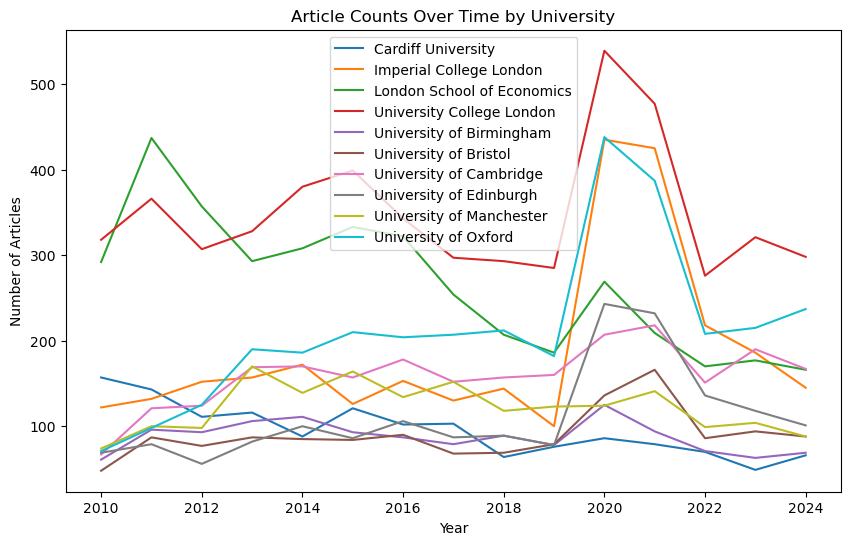

In [5]:
df = pd.read_csv('data/raw/combined_raw.csv')

df['webPublicationDate'] = pd.to_datetime(df['webPublicationDate'])
df['year'] = df['webPublicationDate'].dt.year

counts = df.groupby(['year', 'university']).size().reset_index(name='article_count')

plt.figure(figsize=(10, 6))

for uni in counts['university'].unique():
    subset = counts[counts['university'] == uni]
    plt.plot(subset['year'], subset['article_count'], label=uni)

plt.legend()
plt.title("Article Counts Over Time by University")
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.show()

These line charts demonstrate the article counts of 10 universities, and we can observe the changes and trends over time. 

The first observed pattern is a 'universal peak' of article counts around 2020, when most of the selected universities were mentioned in the media more frequently compared to other years. One major event that happened in 2020 was the breakout of COVID-19, which influenced the majority of the population in the UK, as well as university students. Due to COVID-19, universities had to adjust their teaching mode, i.e., switching to online classes. Together with other associated adjustments, COVID-19 could be a reasonable explanation for this universal increase.

The second observation is that UCL has overall the largest article counts over these years. This is very reasonable, as UCL is one of the most famous universities in the UK, and its size is comparatively larger than the others in this chart, i.e., LSE, Oxford, and Imperial.

Third, we find that some universities display different trends in terms of their article counts. For example, LSE shows a downward trend, and Imperial College shows an upward trend. 

In other times, the article counts of universities almost follow a similar trend. This implies the frequency of news and reports on universities is affected by larger-scale social issues, like COVID-19.

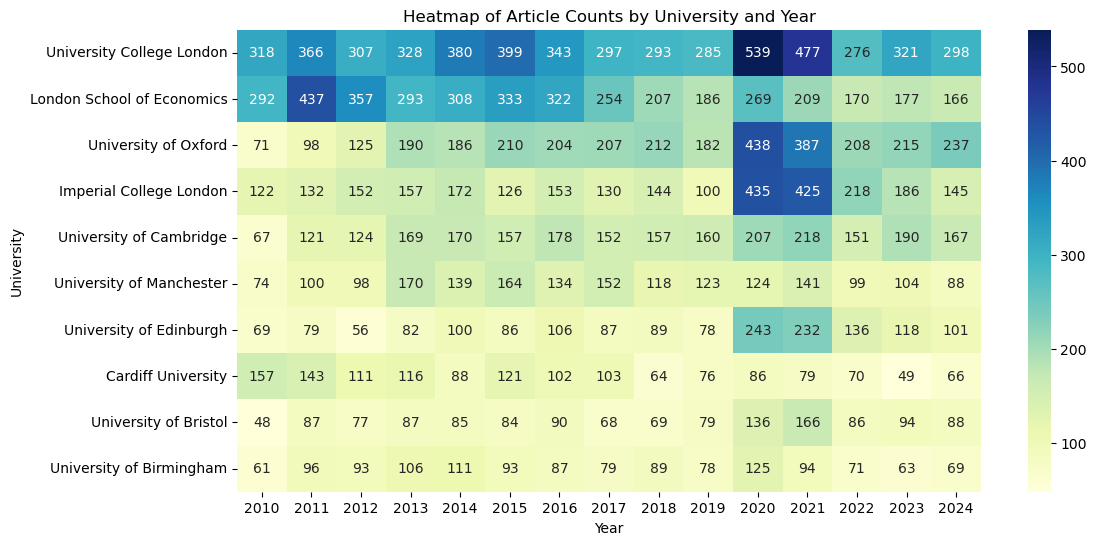

In [6]:
pivot = counts.pivot(
    index='university', 
    columns='year', 
    values='article_count'
).fillna(0)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot, 
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Heatmap of Article Counts by University and Year")
plt.xlabel("Year")
plt.ylabel("University")

plt.show()

This heatmap demonstrates the same information from the line chart, but tells more explicitly about the comparative number of articles related to different universities in different years. From this chart, we can see that there are more articles related to universities in the years 2020 and 2021; and over this 15-year time interval, the top 5 UK universities ('top' in terms of general reputation) have more media coverage than others.

2.2 Further Analysis -- Overlay the major events on the time series

### Major UK events and university coverage

To investigate whether major events produce spikes in university-related coverage, we selected 14 events from 2010–2024 that are either directly connected to higher education or are significant national events that could generate university commentary. Where multiple events fell in the same year, we grouped them together. We categorised them into two groups:

Events directly affecting universities (8): the austerity budget and tuition fee protests in 2010 (fees tripled to £9,000), the start of the new fee regime in 2012, the Scottish independence referendum in 2014 (which affected Scottish university funding and cross-border fees), the Brexit referendum in 2016 (threatening EU research funding and student mobility), Brexit being passed in 2019, the COVID-19 first lockdown and A-level results algorithm controversy in 2020, the third lockdown in 2021, the cost of living crisis in 2022 (which triggered student rent strikes), and the peak of UCU strikes in 2023.

Major national events (6): the 2011 England riots, the 2012 London Olympics, same-sex marriage legislation in 2013, the 2015 Conservative majority, the Grenfell Tower fire and snap election in 2017, and the 2024 Labour election victory.

By comparing these two groups on the same chart, we can examine whether education-related events drive more visible changes in university coverage than general national news.

In [15]:
#events grouped by whether they directly affect universities
events = pd.DataFrame({
    'event': ['Austerity / Tuition fee protests', 
              'England riots', 'New fee regime / London Olympics',
              'Same-sex marriage', 'Scottish independence ref',
              'Conservative majority', 'Brexit referendum',
              'Grenfell Tower / Snap election', 'Brexit passed',
              'First COVID lockdown / A-level algorithm row', 'Third lockdown',
              'Cost of living crisis / Queen Elizabeth dies', 
              'UCU strikes peak', 'Labour wins election'],
    'year': [2010, 2011, 2012, 2013, 2014,
             2015, 2016, 2017, 2019,
             2020, 2021, 2022, 2023, 2024],
    'type': ['direct', 'national', 'direct', 'national', 'direct',
             'national', 'direct', 'national', 'direct',
             'direct', 'direct', 'direct', 'direct', 'national']
})

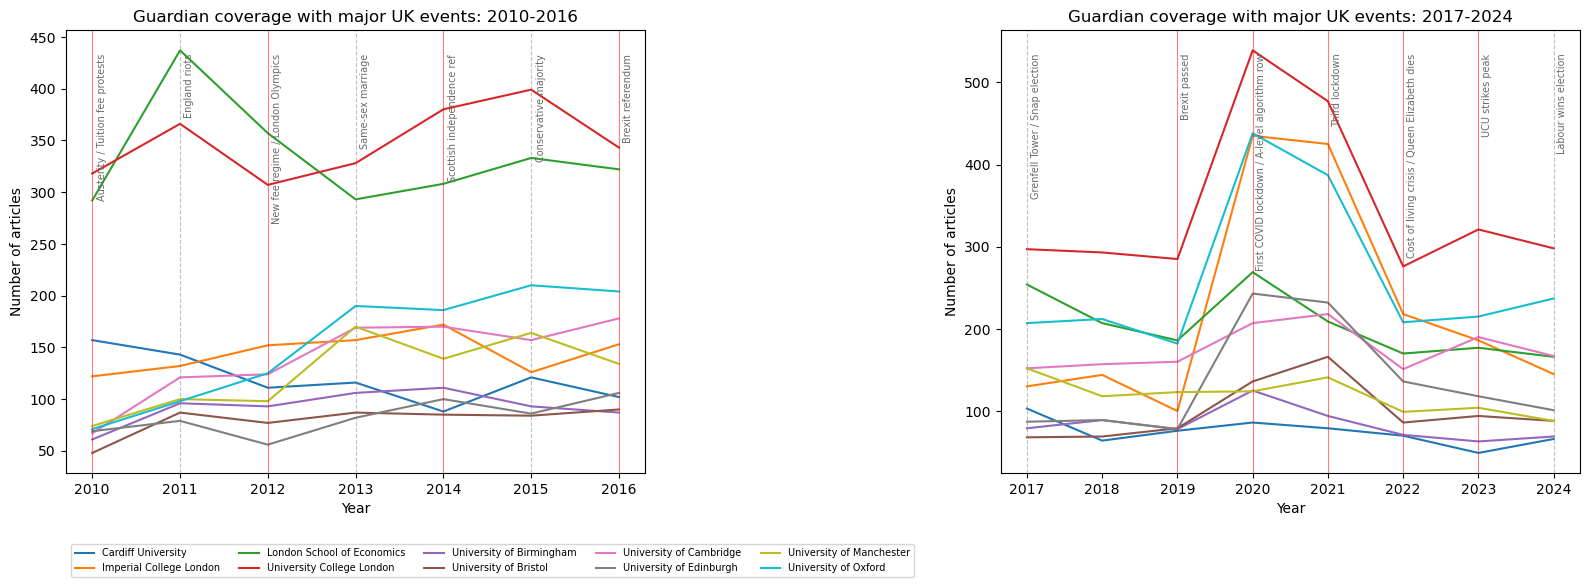

In [16]:
#overlay events on time series - split into two periods for readability
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, year_range, title in [
    (axes[0], range(2010, 2017), '2010-2016'),
    (axes[1], range(2017, 2025), '2017-2024')
]:
    for uni in counts['university'].unique():
        subset = counts[counts['year'].isin(year_range)]
        uni_data = subset[subset['university'] == uni]
        ax.plot(uni_data['year'], uni_data['article_count'], label=uni)
    
    period_events = events[events['year'].isin(year_range)]
    for _, row in period_events.iterrows():
        if row['type'] == 'direct':
            ax.axvline(x=row['year'], color='red', linestyle='-', linewidth=0.8, alpha=0.5)
        else:
            ax.axvline(x=row['year'], color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.text(row['year'] + 0.05, ax.get_ylim()[1] * 0.95, row['event'],
                rotation=90, fontsize=7, va='top', color='dimgrey')
    
    ax.set_title(f'Guardian coverage with major UK events: {title}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of articles')
    ax.set_xticks(list(year_range))

axes[0].legend(bbox_to_anchor=(0, -0.15), loc='upper left', fontsize=7, ncol=5)
plt.tight_layout()
plt.show()

The overlay reveals a clear pattern: events that directly affect universities produce more visible changes in coverage than general national events.

The COVID-19 lockdowns in 2020 and 2021 caused the largest spike across nearly all universities — article counts roughly doubled compared to 2019. This is expected because COVID directly disrupted teaching, assessment, and student welfare. The 2010 tuition fee protests also correspond to a period of increased coverage, though the effect is harder to isolate since it was our first year of data.

In contrast, major national events like Brexit (2016), the London Olympics (2012), and the death of Queen Elizabeth II (2022) do not produce noticeable spikes in university-related article counts. This suggests that the Guardian's university coverage is driven more by events that directly affect higher education than by general national news, even when those events are highly significant.

One notable exception is the 2011 England riots, which coincide with a peak in LSE's coverage relative to other universities. This likely reflects LSE's role as a leading social science institution — its researchers were heavily involved in analysing the causes of the riots, generating media attention for the university specifically.

This analysis has limitations: article counts are aggregated at the yearly level, so we cannot identify spikes at the monthly or weekly level where shorter-term events might show a clearer effect.

3. Analysis on the changes of data

We have observed a big picture of trends in the number of articles related to universities, and we have analysed factors and social events that caused these changes. Now we will demonstrate the movements of data and trends.

3.1 Bar charts -- showing the increases and decreases comparatively

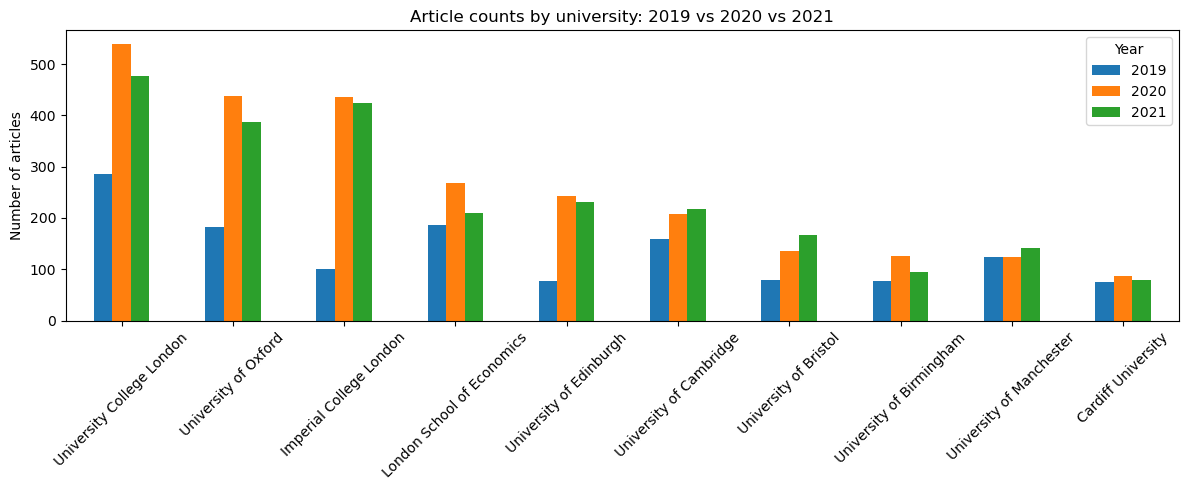

In [21]:
#compare article counts around COVID: 2019 vs 2020 vs 2021
years_to_compare = counts[counts['year'].isin([2019, 2020, 2021])]
pivot_covid = years_to_compare.pivot(index='university', columns='year', values='article_count').fillna(0)
pivot_covid = pivot_covid.sort_values(2020, ascending=False)

pivot_covid.plot(kind='bar', figsize=(12, 5))
plt.title('Article counts by university: 2019 vs 2020 vs 2021')
plt.ylabel('Number of articles')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

From the above bar chart, we found that most of the universities experienced an increase in the number of articles related to them, and in some cases, the increases are close to double and triple. In general, the larger the total amount of media coverage is, the more obvious the increase is. The last 5 universities showed less representative and less obvious increasing trends from 2019 to 2020 and 2021 compared to the top 5 universities. This internal difference could be explained by the size and scale of both the university itself and the amount of media reports related to it.